# Amazon Reviews 2023 Sentiment Pipeline

Notebook nay duoc chuyen tu flow Amazon Reviews 2018 sang **Amazon Reviews 2023**.

Nhung diem da sua:
- Load tu **JSONL**
- Doi schema: `overall -> rating`, `summary -> title`, `reviewText -> text`.
- Dung `parent_asin` de tong hop va ranking san pham.
- Tach **train / validation / test** chuan cho BERT.

Theo README cua Amazon Reviews 2023, `parent_asin` la ID phu hop de gan voi product metadata va phan tich cap san pham.

In [ ]:
import json
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 120)


## 1. Cau hinh du lieu

Nen uu tien file local vi `datasets` moi da khong con ho tro dataset script cua Amazon Reviews 2023 nhu truoc.

Cac cach on dinh:
- `jsonl`: load file local `Electronics.jsonl` hoac `Electronics.jsonl.gz`
- `parquet`: load file local `Electronics.parquet`

Nhanh gon nhat la tai file review Electronics ve may roi doc local.

In [ ]:
import shutil
from pathlib import Path

MOUNT_POINT = Path("/content/drive")
if MOUNT_POINT.exists() and any(MOUNT_POINT.iterdir()) and not (MOUNT_POINT / "MyDrive").exists():
    shutil.rmtree(MOUNT_POINT)

from google.colab import drive
drive.mount(str(MOUNT_POINT), force_remount=True)


Mounted at /content/drive


In [ ]:
DATA_SOURCE = "jsonl"

HF_DATASET_NAME = ""
HF_CONFIG = ""
HF_SPLIT = ""

PROJECT_ROOT = Path("/content/drive/Othercomputers/My Laptop/New project")
DATA_ROOT = PROJECT_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw" / "amazon_reviews_2023" / "reviews"

JSONL_PATH = str(RAW_ROOT / "Electronics.jsonl")
PARQUET_PATH = str(RAW_ROOT / "Electronics.parquet")

SAMPLE_SIZE = 20_000
# SCAN_LIMIT: so dong toi da doc tu file JSONL de LAM PHAM VI lay mau ngau nhien.
# - Phai >= SAMPLE_SIZE.
# - Dat lon hon SAMPLE_SIZE (vd 500k) de mau dai dien hon cho toan dataset.
# - Dat None neu may du RAM va muon lay mau ngau nhien tren TOAN BO file.
SCAN_LIMIT = 500_000
MIN_WORDS = 5
RANDOM_STATE = 42

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "amazon_reviews_2023"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("JSONL_PATH:", JSONL_PATH)

In [ ]:
from pathlib import Path

def check_input_file(data_source: str, jsonl_path: str, parquet_path: str) -> None:
    """Kiem tra file input local ton tai hay chua va in huong dan ro rang."""
    expected_jsonl = Path(jsonl_path)
    expected_parquet = Path(parquet_path) if parquet_path else None

    print("DATA_SOURCE hien tai:", data_source)
    print("Duong dan JSONL mong doi:", expected_jsonl)
    print("Duong dan Parquet mong doi:", expected_parquet)

    if data_source == "jsonl":
        if expected_jsonl.exists():
            print("OK: Da tim thay file review Electronics local.")
        else:
            print("CHUA TIM THAY FILE JSONL.")
            print("Hay dat file review Electronics vao dung duong dan nay:")
            print(expected_jsonl)
            print("Ten file nen la: Electronics.jsonl hoac Electronics.jsonl.gz")
            candidates = list(Path("/content/drive").rglob("Electronics.jsonl"))[:10]
            if candidates:
                print("\nDa tim thay cac file cung ten o vi tri khac:")
                for item in candidates:
                    print(item)
            else:
                print("\nChua tim thay Electronics.jsonl o bat ky dau trong /content/drive.")

    elif data_source == "parquet":
        if expected_parquet and expected_parquet.exists():
            print("OK: Da tim thay file review Electronics local.")
        else:
            print("CHUA TIM THAY FILE PARQUET.")
            print("Hay dat file review Electronics vao dung duong dan nay:")
            print(expected_parquet)
            print("Ten file nen la: Electronics.parquet")

    else:
        print("DATA_SOURCE khong hop le. Hay dung 'jsonl' hoac 'parquet'.")


check_input_file(DATA_SOURCE, JSONL_PATH, PARQUET_PATH)

DATA_SOURCE hien tai: jsonl
Duong dan JSONL mong doi: /content/drive/Othercomputers/My Laptop/New project/data/raw/amazon_reviews_2023/reviews/Electronics.jsonl
Duong dan Parquet mong doi: /content/drive/Othercomputers/My Laptop/New project/data/raw/amazon_reviews_2023/reviews/Electronics.parquet
OK: Da tim thay file review Electronics local.


In [ ]:
def load_amazon_reviews_2023(
    data_source: str,
    jsonl_path: str,
    parquet_path: str = "",
    sample_size: int | None = 20_000,
    random_state: int = 42,
    scan_limit: int | None = 500_000,
) -> "pd.DataFrame":
    """Load raw Amazon Reviews 2023 review data from local files.

    Sua loi sampling: ban cu dung `nrows=sample_size` nen chi lay dung
    `sample_size` dong DAU file roi moi shuffle -> KHONG phai mau ngau nhien
    tu toan bo dataset (de bi bias theo thu tu luu tru cua file).

    Cach moi: doc toi da `scan_limit` dong (de tranh MemoryError voi file rat
    lon) lam pham vi lay mau, sau do lay mau NGAU NHIEN `sample_size` dong.
    Dat `scan_limit=None` neu may du RAM va muon lay mau ngau nhien tren
    TOAN BO file.
    """
    from pathlib import Path
    import pandas as pd

    if data_source == "jsonl":
        file_path = Path(jsonl_path)
        if not file_path.exists():
            raise FileNotFoundError(f"Khong tim thay file JSONL: {file_path}")

        if sample_size is None and scan_limit is None:
            raise RuntimeError(
                "Hay dat SAMPLE_SIZE hoac SCAN_LIMIT vi file JSONL rat lon, "
                "doc full de gay MemoryError."
            )

        if scan_limit is not None and sample_size is not None and scan_limit < sample_size:
            raise ValueError(
                f"SCAN_LIMIT ({scan_limit}) phai >= SAMPLE_SIZE ({sample_size})."
            )

        print(f"Dang doc JSONL tu: {file_path}")
        # Doc toi da scan_limit dong de lam pham vi lay mau (None = doc het file).
        df = pd.read_json(
            file_path, lines=True, compression="infer", nrows=scan_limit
        )
        print(f"Da doc {len(df)} dong tho de lam pham vi lay mau.")

        # Lay mau NGAU NHIEN tu pham vi da doc (thay vi lay dong dau file).
        if sample_size is not None and sample_size < len(df):
            df = df.sample(n=sample_size, random_state=random_state)
        df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    elif data_source == "parquet":
        file_path = Path(parquet_path)
        if not file_path.exists():
            raise FileNotFoundError(f"Khong tim thay file Parquet: {file_path}")

        print(f"Dang doc Parquet tu: {file_path}")
        df = pd.read_parquet(file_path)

        if sample_size is not None and sample_size < len(df):
            df = df.sample(n=sample_size, random_state=random_state).reset_index(drop=True)

    else:
        raise ValueError("DATA_SOURCE phai la 'jsonl' hoac 'parquet'.")

    print(f"Da load xong: {df.shape}")
    return df


raw_df = load_amazon_reviews_2023(
    data_source=DATA_SOURCE,
    jsonl_path=JSONL_PATH,
    parquet_path=PARQUET_PATH,
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    scan_limit=SCAN_LIMIT,
)

print(f"Raw shape: {raw_df.shape}")
print(raw_df.columns.tolist())
raw_df.head(3)

## 2. Chuan hoa schema sang dang de huan luyen sentiment

Notebook cu dung `reviewText`, `summary`, `overall`.

Voi Amazon Reviews 2023 ta doi sang:
- `reviewText` -> `text`
- `summary` -> `title`
- `overall` -> `rating`
- product-level key -> `parent_asin`

In [ ]:
def assign_sentiment_label(rating: float) -> str:
    if rating >= 4:
        return "Positive"
    if rating == 3:
        return "Neutral"
    return "Negative"


def assign_label_id(label: str) -> int:
    mapping = {"Negative": 0, "Neutral": 1, "Positive": 2}
    return mapping[label]


def build_model_text(row: pd.Series) -> str:
    title = str(row.get("title", "") or "").strip()
    body = str(row.get("text", "") or "").strip()
    if title and body:
        return f"{title} {body}"
    return title or body


def normalize_reviews_2023(df: pd.DataFrame, min_words: int = 5) -> pd.DataFrame:
    required_columns = ["rating", "title", "text", "parent_asin", "asin", "timestamp", "user_id"]
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Dataset thieu cac cot: {missing_columns}")

    keep_columns = required_columns + [col for col in ["verified_purchase", "helpful_vote"] if col in df.columns]
    work_df = df[keep_columns].copy()
    if "verified_purchase" not in work_df.columns:
        work_df["verified_purchase"] = None
    if "helpful_vote" not in work_df.columns:
        work_df["helpful_vote"] = None

    work_df["title"] = work_df["title"].fillna("").astype(str)
    work_df["text"] = work_df["text"].fillna("").astype(str)
    work_df["rating"] = pd.to_numeric(work_df["rating"], errors="coerce")
    work_df = work_df.dropna(subset=["rating", "text", "parent_asin"])

    work_df["model_text"] = work_df.apply(build_model_text, axis=1)
    work_df["word_count"] = work_df["model_text"].str.split().str.len()
    work_df = work_df[work_df["word_count"] >= min_words].copy()

    work_df = work_df.drop_duplicates(subset=["user_id", "parent_asin", "timestamp", "model_text"])
    work_df["sentiment_label"] = work_df["rating"].apply(assign_sentiment_label)
    work_df["label_id"] = work_df["sentiment_label"].apply(assign_label_id)

    return work_df.reset_index(drop=True)


df = normalize_reviews_2023(raw_df, min_words=MIN_WORDS)
print(df.shape)
df.head(3)


(18986, 13)


,rating,title,text,parent_asin,asin,timestamp,user_id,verified_purchase,helpful_vote,model_text,word_count,sentiment_label,label_id
0,5,Get back Control,This little baby is the ultimate value for the money .I have a seven year old Phillips sound bar that I absolutely l...,B08GZBSHWH,B08GZBSHWH,2021-03-16 03:19:03.540,AGRNDVI5ZS2V6UHMEFPECW7MQVIA,True,0,Get back Control This little baby is the ultimate value for the money .I have a seven year old Phillips sound bar th...,167,Positive,2
1,5,Great Design,"If you could use an extra outlet and charging port, this is fabulous. Will be wonderful for hotel travel and for my...",B0C3TLTQGR,B09VX5VB1F,2023-01-25 12:34:58.733,AEZ26WGWJ3EOQ4KWSHG77HJAG4EA,False,0,"Great Design If you could use an extra outlet and charging port, this is fabulous. Will be wonderful for hotel trav...",52,Positive,2
2,5,Exactly what I needed,Great product,B08CVGBDC3,B08CVGBDC3,2022-10-29 02:17:48.350,AFCV25KA7XSAJGTZRDML5B7UYOVQ,True,0,Exactly what I needed Great product,6,Positive,2


In [ ]:
display(df["sentiment_label"].value_counts())
display(df["rating"].value_counts().sort_index())
print("Unique parent_asin:", df["parent_asin"].nunique())

df.to_csv(PROCESSED_DIR / "amazon_reviews_2023_electronics_labeled.csv", index=False)
print("Saved:", PROCESSED_DIR / "amazon_reviews_2023_electronics_labeled.csv")

,count
sentiment_label,
Positive,15551
Negative,2157
Neutral,1278


,count
rating,
1,1427
2,730
3,1278
4,2743
5,12808


Unique parent_asin: 15320
Saved: /content/drive/Othercomputers/My Laptop/New project/data/processed/amazon_reviews_2023_electronics_labeled.csv


## 3. EDA nhanh

Kiem tra nhanh phan bo rating va do dai review sau khi chuan hoa schema.

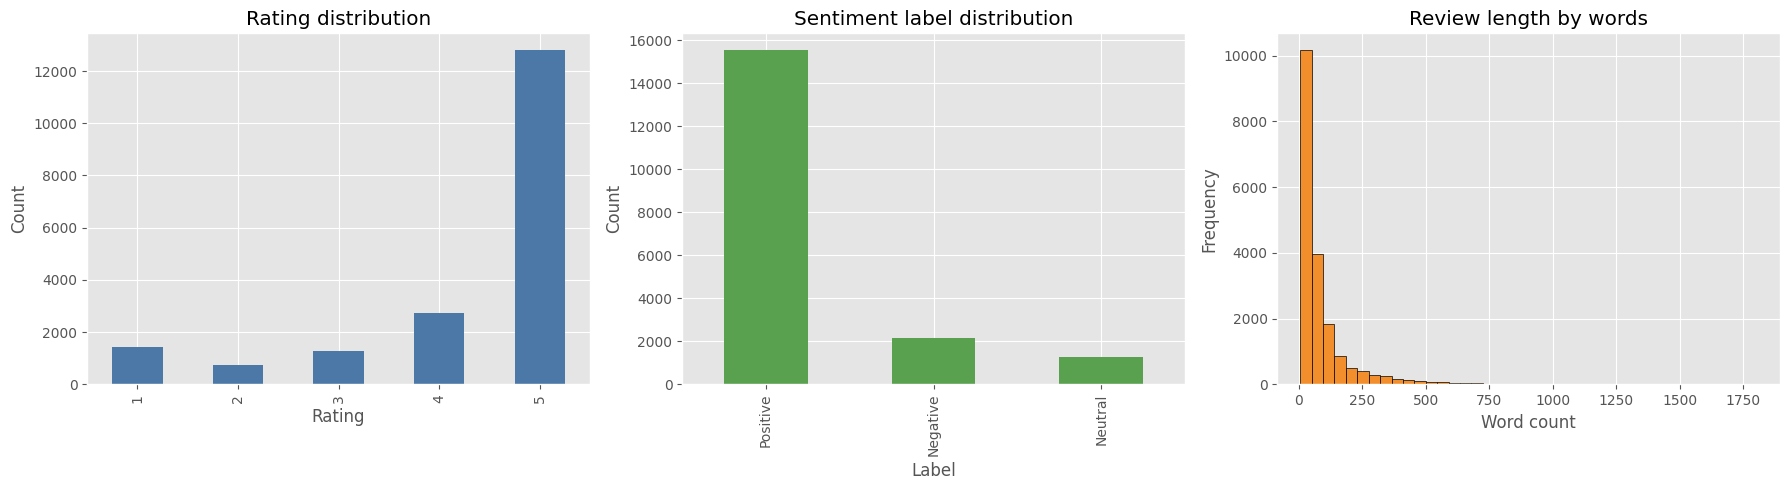

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

df["sentiment_label"].value_counts().plot(kind="bar", ax=axes[1], color="#59A14F")
axes[1].set_title("Sentiment label distribution")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")

df["word_count"].plot(kind="hist", bins=40, ax=axes[2], color="#F28E2B", edgecolor="black")
axes[2].set_title("Review length by words")
axes[2].set_xlabel("Word count")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Can bang dataset va tach train / validation / test

Buoc nay can bang dataset ve 33/33/33 truoc, sau do moi tach train/validation/test.

- Negative = 33.33%
- Neutral = 33.33%
- Positive = 33.33%

Sau khi can bang, ta van tach:
- Train: 70%
- Validation: 15%
- Test: 15%

Tat ca deu stratify theo `label_id` de giu ti le nhan.

In [ ]:
def build_balanced_df(
    df: pd.DataFrame,
    label_column: str = "sentiment_label",
    random_state: int = 42,
):
    label_order = ["Negative", "Neutral", "Positive"]
    min_count = int(df[label_column].value_counts().reindex(label_order).min())
    balanced_parts = [
        df[df[label_column] == label].sample(n=min_count, random_state=random_state)
        for label in label_order
    ]
    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    return balanced_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)


balanced_df = build_balanced_df(df, label_column="sentiment_label", random_state=RANDOM_STATE)
display(balanced_df["sentiment_label"].value_counts())
display(balanced_df["sentiment_label"].value_counts(normalize=True).rename("balanced_ratio"))

balanced_df.to_csv(PROCESSED_DIR / "amazon_reviews_2023_electronics_labeled_balanced.csv", index=False)
print("Saved:", PROCESSED_DIR / "amazon_reviews_2023_electronics_labeled_balanced.csv")


def split_train_val_test(
    df: pd.DataFrame,
    text_column: str = "model_text",
    label_column: str = "label_id",
    test_size: float = 0.15,
    val_size: float = 0.15,
    random_state: int = 42,
):
    train_df, temp_df = train_test_split(
        df,
        test_size=test_size + val_size,
        random_state=random_state,
        stratify=df[label_column],
    )

    relative_val_size = val_size / (test_size + val_size)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=1 - relative_val_size,
        random_state=random_state,
        stratify=temp_df[label_column],
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


train_df, val_df, test_df = split_train_val_test(
    balanced_df,
    text_column="model_text",
    label_column="label_id",
    test_size=0.15,
    val_size=0.15,
    random_state=RANDOM_STATE,
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df["sentiment_label"].value_counts(normalize=True).rename("train_ratio"))
display(val_df["sentiment_label"].value_counts(normalize=True).rename("val_ratio"))
display(test_df["sentiment_label"].value_counts(normalize=True).rename("test_ratio"))

,count
sentiment_label,
Positive,1278
Neutral,1278
Negative,1278


,balanced_ratio
sentiment_label,
Positive,0.333333
Neutral,0.333333
Negative,0.333333


Saved: /content/drive/Othercomputers/My Laptop/New project/data/processed/amazon_reviews_2023_electronics_labeled_balanced.csv
Train shape: (2683, 13)
Validation shape: (575, 13)
Test shape: (576, 13)


,train_ratio
sentiment_label,
Negative,0.333582
Positive,0.333209
Neutral,0.333209


,val_ratio
sentiment_label,
Positive,0.333913
Neutral,0.333913
Negative,0.332174


,test_ratio
sentiment_label,
Neutral,0.333333
Negative,0.333333
Positive,0.333333


## 5. Xuat file CSV tuong thich cac script model

Cac script baseline/CNN/LSTM/BERT hien tai trong project deu ky vong cot `reviewText` va `sentiment_label`.

Vi vay ta tao 2 file processed:
- mot file full de predict/ranking
- mot file balanced de train model compare

Ca hai van giu them `title`, `text`, `rating`, `parent_asin` de phuc vu ranking va dashboard.

In [ ]:
MODEL_INPUT_PATH = PROCESSED_DIR / "amazon_reviews_2023_electronics_for_models.csv"
MODEL_INPUT_BALANCED_PATH = PROCESSED_DIR / "amazon_reviews_2023_electronics_for_models_balanced.csv"

model_df = df.copy()
model_df["reviewText"] = model_df["model_text"]
model_df["summary"] = model_df["title"]
model_df["overall"] = model_df["rating"]

balanced_model_df = balanced_df.copy()
balanced_model_df["reviewText"] = balanced_model_df["model_text"]
balanced_model_df["summary"] = balanced_model_df["title"]
balanced_model_df["overall"] = balanced_model_df["rating"]

export_columns = [
    "reviewText",
    "summary",
    "overall",
    "rating",
    "title",
    "text",
    "asin",
    "parent_asin",
    "user_id",
    "timestamp",
    "verified_purchase",
    "helpful_vote",
    "sentiment_label",
    "label_id",
]

model_df[export_columns].to_csv(MODEL_INPUT_PATH, index=False)
balanced_model_df[export_columns].to_csv(MODEL_INPUT_BALANCED_PATH, index=False)
print("Saved full model-ready CSV:", MODEL_INPUT_PATH)
print("Full shape:", model_df[export_columns].shape)
print("Saved balanced model-ready CSV:", MODEL_INPUT_BALANCED_PATH)
print("Balanced shape:", balanced_model_df[export_columns].shape)
balanced_model_df[export_columns].head(3)

Saved full model-ready CSV: /content/drive/Othercomputers/My Laptop/New project/data/processed/amazon_reviews_2023_electronics_for_models.csv
Full shape: (18986, 14)
Saved balanced model-ready CSV: /content/drive/Othercomputers/My Laptop/New project/data/processed/amazon_reviews_2023_electronics_for_models_balanced.csv
Balanced shape: (3834, 14)


,reviewText,summary,overall,rating,title,text,asin,parent_asin,user_id,timestamp,verified_purchase,helpful_vote,sentiment_label,label_id
0,"High quality power strip, that is smart to boot... THE GOOD:<br />---------------<br />* It's smart! You'll be using...","High quality power strip, that is smart to boot...",5,5,"High quality power strip, that is smart to boot...",THE GOOD:<br />---------------<br />* It's smart! You'll be using the smart life app.<br />* Smart Life can be linke...,B0BL38D82X,B0BL38D82X,AHR6RGZTLOMBD7EBF3OK43JWMGNQ,2023-01-21 00:26:34.724,False,1,Positive,2
1,"Disappointing, but it does work (kind of) The first time I plugged in the Wi-Fi adapter, the TV froze. I tried it a...","Disappointing, but it does work (kind of)",3,3,"Disappointing, but it does work (kind of)","The first time I plugged in the Wi-Fi adapter, the TV froze. I tried it again with the TV turned off and then it wo...",B07CM5NZRC,B07CM5NZRC,AFAIJYOUO3NAWLBDIKTQSC3DASWA,2019-03-02 23:43:20.185,False,2,Neutral,1
2,"DOA I have the same monitor and decided to go to a dual set up. I unpacked and assembled the new monitor, connected ...",DOA,1,1,DOA,"I have the same monitor and decided to go to a dual set up. I unpacked and assembled the new monitor, connected the ...",B096TFPYQZ,B096TFPYQZ,AFRZT4CA3LWX5ITFOWONN2KPKCFA,2021-09-21 11:13:41.726,True,0,Negative,0


## 6. Train cac model compare

Flow nay giu tinh than notebook cu: train nhieu model roi so sanh de tim model tot nhat.

Goi y cho laptop:
- Baseline: nen chay
- CNN: nen chay
- LSTM: nen chay
- BERT: nen dat `False` neu may khong co GPU

Neu muon BERT manh hon, dung file CSV nay tren Colab GPU.

In [ ]:
RUN_BASELINE = True
RUN_CNN = True
RUN_LSTM = True
RUN_BERT = True

CNN_EPOCHS = 4
LSTM_EPOCHS = 4
BERT_EPOCHS = 2
BERT_SAMPLE_SIZE = None

PYTHON_EXE = Path(sys.executable)
PROJECT_ROOT = PROJECT_ROOT

def run_script(script_relative_path: str, args: list[str]) -> None:
    script_path = PROJECT_ROOT / script_relative_path
    command = [str(PYTHON_EXE), str(script_path)] + args
    print("Running:", " ".join(command))
    subprocess.run(command, check=True, cwd=PROJECT_ROOT)

print("Python exe:", PYTHON_EXE)
print("Project root:", PROJECT_ROOT)


Python exe: /usr/bin/python3
Project root: /content/drive/Othercomputers/My Laptop/New project


In [ ]:
if RUN_BASELINE:
    run_script(
        "ml/scripts/train_tfidf_logreg_baseline.py",
        ["--input", str(MODEL_INPUT_BALANCED_PATH), "--test-size", "0.15"],
    )


Running: /usr/bin/python3 /content/drive/Othercomputers/My Laptop/New project/ml/scripts/train_tfidf_logreg_baseline.py --input /content/drive/Othercomputers/My Laptop/New project/data/processed/amazon_reviews_2023_electronics_for_models_balanced.csv --test-size 0.15


In [ ]:
if RUN_CNN:
    run_script(
        "ml/scripts/train_cnn_sentiment.py",
        [
            "--input", str(MODEL_INPUT_BALANCED_PATH),
            "--epochs", str(CNN_EPOCHS),
            "--batch-size", "64",
            "--test-size", "0.15",
            "--val-size", "0.15",
            "--random-state", str(RANDOM_STATE),
        ],
    )


Running: /usr/bin/python3 /content/drive/Othercomputers/My Laptop/New project/ml/scripts/train_cnn_sentiment.py --input /content/drive/Othercomputers/My Laptop/New project/data/processed/amazon_reviews_2023_electronics_for_models_balanced.csv --epochs 4 --batch-size 64 --test-size 0.15 --val-size 0.15 --random-state 42


In [ ]:
if RUN_LSTM:
    # SUA LOI SO SANH KHONG CONG BANG:
    # Truoc day LSTM dung MODEL_INPUT_PATH (file day du, MAT CAN BANG) trong khi
    # baseline/CNN/BERT dung MODEL_INPUT_BALANCED_PATH. Ket qua 4 model hoc va
    # danh gia tren phan phoi du lieu khac nhau -> bang so sanh khong hop le.
    # Nay LSTM dung CHUNG file balanced de so sanh dung tren cung dieu kien.
    run_script(
        "ml/scripts/train_lstm_sentiment.py",
        [
            "--input", str(MODEL_INPUT_BALANCED_PATH),
            "--epochs", str(LSTM_EPOCHS),
            "--batch-size", "64",
            "--test-size", "0.15",
            "--val-size", "0.15",
            "--random-state", str(RANDOM_STATE),
        ],
    )

In [ ]:
if RUN_BERT:
    bert_args = [
        "--input", str(MODEL_INPUT_BALANCED_PATH),
        "--epochs", str(BERT_EPOCHS),
        "--batch-size", "8",
        "--max-len", "128",
        "--test-size", "0.15",
        "--val-size", "0.15",
        "--random-state", str(RANDOM_STATE),
    ]
    if BERT_SAMPLE_SIZE is not None:
        bert_args.extend(["--sample-size", str(BERT_SAMPLE_SIZE)])

    run_script("ml/scripts/train_bert_sentiment.py", bert_args)
else:
    print("Bo qua BERT local. Neu can, dung file CSV nay tren Colab GPU.")


Running: /usr/bin/python3 /content/drive/Othercomputers/My Laptop/New project/ml/scripts/train_bert_sentiment.py --input /content/drive/Othercomputers/My Laptop/New project/data/processed/amazon_reviews_2023_electronics_for_models_balanced.csv --epochs 2 --batch-size 8 --max-len 128 --test-size 0.15 --val-size 0.15 --random-state 42


## 7. Tong hop ket qua va chon model tot nhat

Uu tien so sanh theo **macro F1** vi bai toan sentiment 3 lop thuong mat can bang.

In [ ]:
run_script("ml/scripts/compare_model_results.py", ["--stale-threshold-hours", "12"])

comparison_path = PROJECT_ROOT / "outputs/model_comparison/model_comparison.csv"
commentary_path = PROJECT_ROOT / "outputs/model_comparison/auto_commentary_vi.txt"

comparison_df = pd.read_csv(comparison_path)
display(comparison_df)
print(commentary_path.read_text(encoding="utf-8"))

available_df = comparison_df.dropna(subset=["macro_f1"]).copy()
best_row = available_df.sort_values(["macro_f1", "accuracy"], ascending=False).iloc[0]
print(f"\nModel tot nhat hien tai: {best_row['model_name']}")
print(f"Macro F1: {best_row['macro_f1']:.4f}")
print(f"Accuracy: {best_row['accuracy']:.4f}")


## 8. Ranking san pham theo `parent_asin`

**Luu y quan trong (proxy):** phan ranking nay dung `sentiment_label` duoc suy
TRUC TIEP tu `rating` (1-2 sao = Negative, 3 = Neutral, 4-5 = Positive), CHU KHONG
phai `predicted_sentiment` tu model. Tuc la ranking hien tai khong dung output cua
ML; no chi tong hop lai rating. Day la phien ban demo/baseline cho ranking.

De ranking thuc su dung model: chay model tot nhat de sinh cot `predicted_sentiment`
cho tung review, roi goi `build_product_ranking(df, label_column="predicted_sentiment")`.
Ham ben duoi da ho tro tham so `label_column` de doi nguon nhan ma khong sua logic.

Voi Amazon Reviews 2023, ranking cap san pham nen tong hop theo `parent_asin`.

Cong thuc:
- Negative = 1, Neutral = 2, Positive = 3
- `potential_score = 0.7 * normalized_sentiment_mean + 0.3 * normalized_review_volume`

**Canh bao ve du lieu:** neu hau het san pham chi co 1 review (so `parent_asin`
unique gan bang so review), thi `review_count` gan nhu deu nhau -> thanh phan
volume khong con phan biet duoc san pham. Ham `min_max_normalize` da sua de trong
truong hop nay tra ve 0.0 (khong tao tin hieu gia), thay vi 1.0 nhu truoc.

In [ ]:
def min_max_normalize(series: pd.Series) -> pd.Series:
    """Chuan hoa min-max ve [0, 1].

    SUA: khi tat ca gia tri bang nhau (max == min), ban cu tra ve toan 1.0.
    Voi cot `review_count` ma moi san pham deu co 1 review, dieu nay khien
    thanh phan volume bi day len 1.0 cho TAT CA san pham -> tao tin hieu gia.
    Nay tra ve 0.0 (trung tinh, khong dong gop tin hieu) cho dung hon.
    """
    min_value = series.min()
    max_value = series.max()
    if max_value == min_value:
        return pd.Series([0.0] * len(series), index=series.index)
    return (series - min_value) / (max_value - min_value)


def build_product_ranking(
    df: pd.DataFrame,
    product_column: str = "parent_asin",
    label_column: str = "sentiment_label",
    score_weights: tuple[float, float] = (0.7, 0.3),
) -> pd.DataFrame:
    """Ranking san pham theo diem tiem nang.

    `label_column`: cot nhan cam xuc dung de tinh diem.
      - "sentiment_label" (mac dinh): nhan suy tu rating (phien ban proxy).
      - "predicted_sentiment": nhan do model du doan (phien ban dung ML).
    """
    sentiment_score_map = {"Negative": 1, "Neutral": 2, "Positive": 3}
    work_df = df.copy()
    work_df["sentiment_score"] = work_df[label_column].map(sentiment_score_map)

    ranking_df = (
        work_df.groupby(product_column)
        .agg(
            review_count=(product_column, "size"),
            sentiment_score_mean=("sentiment_score", "mean"),
            positive_ratio=(label_column, lambda x: (x == "Positive").mean()),
            negative_ratio=(label_column, lambda x: (x == "Negative").mean()),
        )
        .reset_index()
    )

    ranking_df["normalized_sentiment_mean"] = min_max_normalize(ranking_df["sentiment_score_mean"])
    ranking_df["normalized_review_volume"] = min_max_normalize(ranking_df["review_count"])

    ranking_df["product_potential_score"] = (
        score_weights[0] * ranking_df["normalized_sentiment_mean"]
        + score_weights[1] * ranking_df["normalized_review_volume"]
    )

    ranking_df = ranking_df.sort_values("product_potential_score", ascending=False).reset_index(drop=True)
    return ranking_df


# Kiem tra phan bo so review/san pham truoc khi tin vao ranking.
reviews_per_product = df.groupby("parent_asin").size()
print("So san pham (parent_asin):", reviews_per_product.shape[0])
print("So review trung binh / san pham:", round(reviews_per_product.mean(), 3))
print("So san pham chi co 1 review:", int((reviews_per_product == 1).sum()),
      f"({(reviews_per_product == 1).mean():.1%})")
if (reviews_per_product == 1).mean() > 0.9:
    print("CANH BAO: >90% san pham chi co 1 review -> thanh phan volume gan nhu vo nghia.")

# Phien ban proxy (dung nhan suy tu rating). Doi label_column='predicted_sentiment'
# sau khi da sinh du doan tu model tot nhat de co ranking dung ML.
product_ranking_df = build_product_ranking(
    df,
    product_column="parent_asin",
    label_column="sentiment_label",
    score_weights=(0.7, 0.3),
)
product_ranking_df.head(10)

In [ ]:
ranking_path = OUTPUT_DIR / "amazon_reviews_2023_product_ranking.csv"
product_ranking_df.to_csv(ranking_path, index=False)
print("Saved:", ranking_path)

top_10 = product_ranking_df.head(10)
plt.figure(figsize=(12, 5))
plt.bar(top_10["parent_asin"], top_10["product_potential_score"], color="#4E79A7")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 products by potential score (parent_asin)")
plt.xlabel("parent_asin")
plt.ylabel("product_potential_score")
plt.tight_layout()
plt.show()

## 9. Ghi chu mapping tu notebook cu sang dataset moi

De giu suong bai cua notebook cu, team nen nho mapping sau:

- `df['overall']` -> `df['rating']`
- `df['summary']` -> `df['title']`
- `df['reviewText']` -> `df['text']`
- text dua vao model -> `df['model_text']`
- product-level key -> `df['parent_asin']`
- file train script -> cot `reviewText` tao tu `title + text`
- BERT evaluation trong luc train -> dung `validation`, khong dung `test`

Sau khi chon best checkpoint tren validation set, moi danh gia cuoi tren `test_df`.